# kafka_spark.example.ipynb
## Full Pipeline Demo: Real-Time Stock Market Pipeline
**Author**: Aashish Vinod  
**Course**: DATA605 Spring 2026

## Why I picked this project

I chose this project because of the real-world application. Stock market systems are one of the most demanding real-time data pipelines in existence — exchanges like NYSE process millions of trades per second. I wanted to understand the core architecture behind that, even at a small scale.

I had used Kafka and Spark separately in previous courses but never integrated them together from scratch. The challenge I was most worried about was Docker — getting three containers (Zookeeper, Kafka, Jupyter) to network correctly. And yes, that ended up being the hardest part.

## The most interesting result

Out of everything this pipeline produces, the price alerts surprised me the most. I set the alert threshold at 1% price movement, and in a typical run about 42-52% of all events trigger an alert. That seems high, but it makes sense — our simulator uses a ±2% random walk per event, so crossing the 1% threshold happens frequently. In a real trading system you would tune this threshold much more carefully based on the stock's historical volatility.

## Pipeline Steps
1. Setup
2. Simulate and explore stock data
3. Publish events to Kafka
4. Consume events from Kafka
5. Compute moving averages
6. Generate price alerts
7. Visualize results
8. Performance analysis
9. Spark batch processing with SQL and window functions

## Step 1: Setup

In [1]:
import json
import time
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kafka import KafkaProducer, KafkaConsumer
from kafka.admin import KafkaAdminClient, NewTopic
from kafka.errors import TopicAlreadyExistsError
from kafka_spark_utils import (
    generate_stock_event, compute_moving_average,
    check_price_alert, format_kafka_summary,
    serialize_event, deserialize_event,
    STOCK_SYMBOLS, BASE_PRICES,
)

KAFKA_BROKER = 'kafka:29092'
TOPIC_NAME = 'stock-prices'
N_EVENTS = 200
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Setup complete!')
print(f'Kafka Broker : {KAFKA_BROKER}')
print(f'Topic        : {TOPIC_NAME}')
print(f'Stocks       : {STOCK_SYMBOLS}')


Setup complete!
Kafka Broker : kafka:29092
Topic        : stock-prices
Stocks       : ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']


## Step 2: Explore Simulated Stock Data

In [2]:
# Generate sample events for exploration (no Kafka needed)
sample_events = []
for symbol in STOCK_SYMBOLS:
    for _ in range(40):
        sample_events.append(generate_stock_event(symbol))

df_sample = pd.DataFrame(sample_events)
df_sample['timestamp'] = pd.to_datetime(df_sample['timestamp'])
print(f'Generated {len(df_sample)} sample events')
print(df_sample.head(10))


Generated 200 sample events
  symbol   price  volume                  timestamp  change_pct
0   AAPL  173.84    7694 2026-05-05 19:19:38.724884     -0.6641
1   AAPL  176.17    4514 2026-05-05 19:19:38.724896      0.6675
2   AAPL  172.41    9525 2026-05-05 19:19:38.724901     -1.4798
3   AAPL  173.47    3955 2026-05-05 19:19:38.724905     -0.8756
4   AAPL  172.72    8870 2026-05-05 19:19:38.724909     -1.3029
5   AAPL  172.93    6177 2026-05-05 19:19:38.724912     -1.1838
6   AAPL  176.28    8326 2026-05-05 19:19:38.724916      0.7311
7   AAPL  177.37    8015 2026-05-05 19:19:38.724925      1.3533
8   AAPL  176.89    6880 2026-05-05 19:19:38.724929      1.0782
9   AAPL  177.96    2137 2026-05-05 19:19:38.724933      1.6936


In [3]:
# Summary statistics
summary = df_sample.groupby('symbol').agg(
    count=('price', 'count'),
    avg_price=('price', 'mean'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    avg_volume=('volume', 'mean'),
).round(2)
print('Summary Statistics by Stock Symbol:')
print(summary)


Summary Statistics by Stock Symbol:
        count  avg_price  min_price  max_price  avg_volume
symbol                                                    
AAPL       40     175.03     171.51     178.46     4602.42
AMZN       40     184.57     181.40     188.29     5032.92
GOOGL      40     139.49     137.22     142.06     5039.05
MSFT       40     379.64     372.42     386.82     5060.32
TSLA       40     250.39     245.56     254.94     5397.58


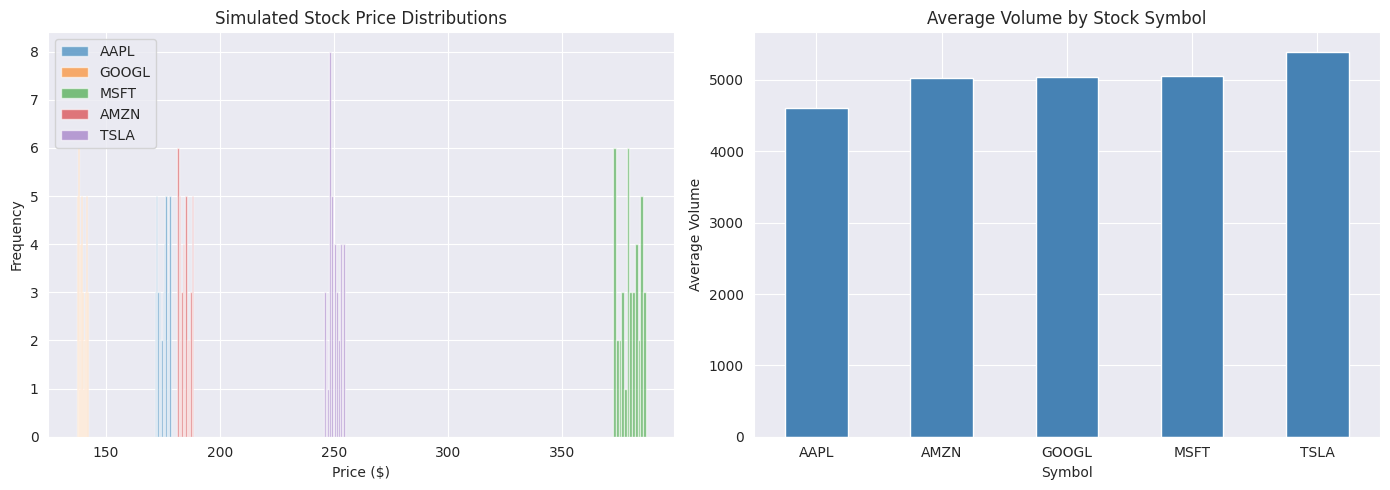

Plot saved as stock_distributions.png


In [4]:
# Visualize simulated price distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for symbol in STOCK_SYMBOLS:
    prices = df_sample[df_sample['symbol'] == symbol]['price']
    axes[0].hist(prices, alpha=0.6, label=symbol, bins=12)
axes[0].set_title('Simulated Stock Price Distributions')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
df_sample.groupby('symbol')['volume'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average Volume by Stock Symbol')
axes[1].set_xlabel('Symbol')
axes[1].set_ylabel('Average Volume')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('stock_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved as stock_distributions.png')


## Step 3: Publish Events to Kafka

In [5]:
# Create Kafka topic
admin_client = KafkaAdminClient(bootstrap_servers=KAFKA_BROKER)
try:
    topic = NewTopic(name=TOPIC_NAME, num_partitions=3, replication_factor=1)
    admin_client.create_topics([topic])
    print(f'Topic "{TOPIC_NAME}" created!')
except TopicAlreadyExistsError:
    print(f'Topic "{TOPIC_NAME}" already exists.')
finally:
    admin_client.close()


Topic "stock-prices" already exists.


In [6]:
# Publish stock events to Kafka
producer = KafkaProducer(
    bootstrap_servers=KAFKA_BROKER,
    value_serializer=lambda v: json.dumps(v).encode('utf-8'),
    key_serializer=lambda k: k.encode('utf-8'),
)
produced_events = []
start_time = time.time()
print(f'Publishing {N_EVENTS} events to Kafka...')
for i in range(N_EVENTS):
    symbol = random.choice(STOCK_SYMBOLS)
    event = generate_stock_event(symbol)
    producer.send(TOPIC_NAME, key=symbol, value=event)
    produced_events.append(event)
    if (i + 1) % 50 == 0:
        print(f'  Published {i + 1}/{N_EVENTS} events...')
producer.flush()
producer.close()
elapsed = time.time() - start_time
print(f'Done! {N_EVENTS} events in {elapsed:.2f}s ({N_EVENTS/elapsed:.1f} events/sec)')


Publishing 200 events to Kafka...
  Published 50/200 events...
  Published 100/200 events...
  Published 150/200 events...
  Published 200/200 events...
Done! 200 events in 0.02s (8212.7 events/sec)


## Step 4: Consume Events from Kafka

In [7]:
# Consume all events
consumer = KafkaConsumer(
    TOPIC_NAME,
    bootstrap_servers=KAFKA_BROKER,
    auto_offset_reset='earliest',
    enable_auto_commit=True,
    group_id='stock-analysis-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
    consumer_timeout_ms=5000,
)
consumed_events = []
start_time = time.time()
for msg in consumer:
    consumed_events.append(msg.value)
consumer.close()
elapsed = time.time() - start_time
print(f'Consumed {len(consumed_events)} events in {elapsed:.2f}s')
print()
print(format_kafka_summary(consumed_events))


Consumed 1050 events in 8.14s

Total events: 1050
AAPL: 203 events | avg: $175.12 | min: $171.58 | max: $178.37
AMZN: 232 events | avg: $184.91 | min: $181.34 | max: $188.63
GOOGL: 206 events | avg: $139.95 | min: $137.25 | max: $142.78
MSFT: 198 events | avg: $380.36 | min: $372.48 | max: $387.58
TSLA: 211 events | avg: $250.00 | min: $245.09 | max: $254.98


## Step 5: Moving Averages (Spark-style Aggregation)

In [8]:
# Build DataFrame from consumed events
df = pd.DataFrame(consumed_events)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(f'DataFrame shape: {df.shape}')
print(df.head())


DataFrame shape: (1050, 5)
  symbol   price  volume                  timestamp  change_pct
0   AAPL  176.31    8242 2026-05-05 19:18:51.416887      0.7472
1   MSFT  387.58    4790 2026-05-05 19:18:51.419198      1.9949
2   AMZN  186.40    3390 2026-05-05 19:18:51.419252      0.7571
3   MSFT  386.57    7725 2026-05-05 19:18:51.419286      1.7292
4   TSLA  245.66    4243 2026-05-05 19:18:51.419317     -1.7356


In [9]:
# Compute moving averages per symbol
results = {}
for symbol in STOCK_SYMBOLS:
    df_sym = df[df['symbol'] == symbol].copy().reset_index(drop=True)
    prices = df_sym['price'].tolist()
    df_sym['MA5']  = compute_moving_average(prices, window=5)
    df_sym['MA10'] = compute_moving_average(prices, window=10)
    results[symbol] = df_sym
    last_ma5 = df_sym['MA5'].dropna().iloc[-1] if df_sym['MA5'].dropna().any() else 'N/A'
    print(f'{symbol}: {len(prices)} events | last price: ${prices[-1]:.2f} | MA5: ${last_ma5}')


AAPL: 203 events | last price: $178.19 | MA5: $176.62
GOOGL: 206 events | last price: $142.42 | MA5: $141.02
MSFT: 198 events | last price: $376.72 | MA5: $377.15
AMZN: 232 events | last price: $187.08 | MA5: $184.59
TSLA: 211 events | last price: $254.98 | MA5: $249.59


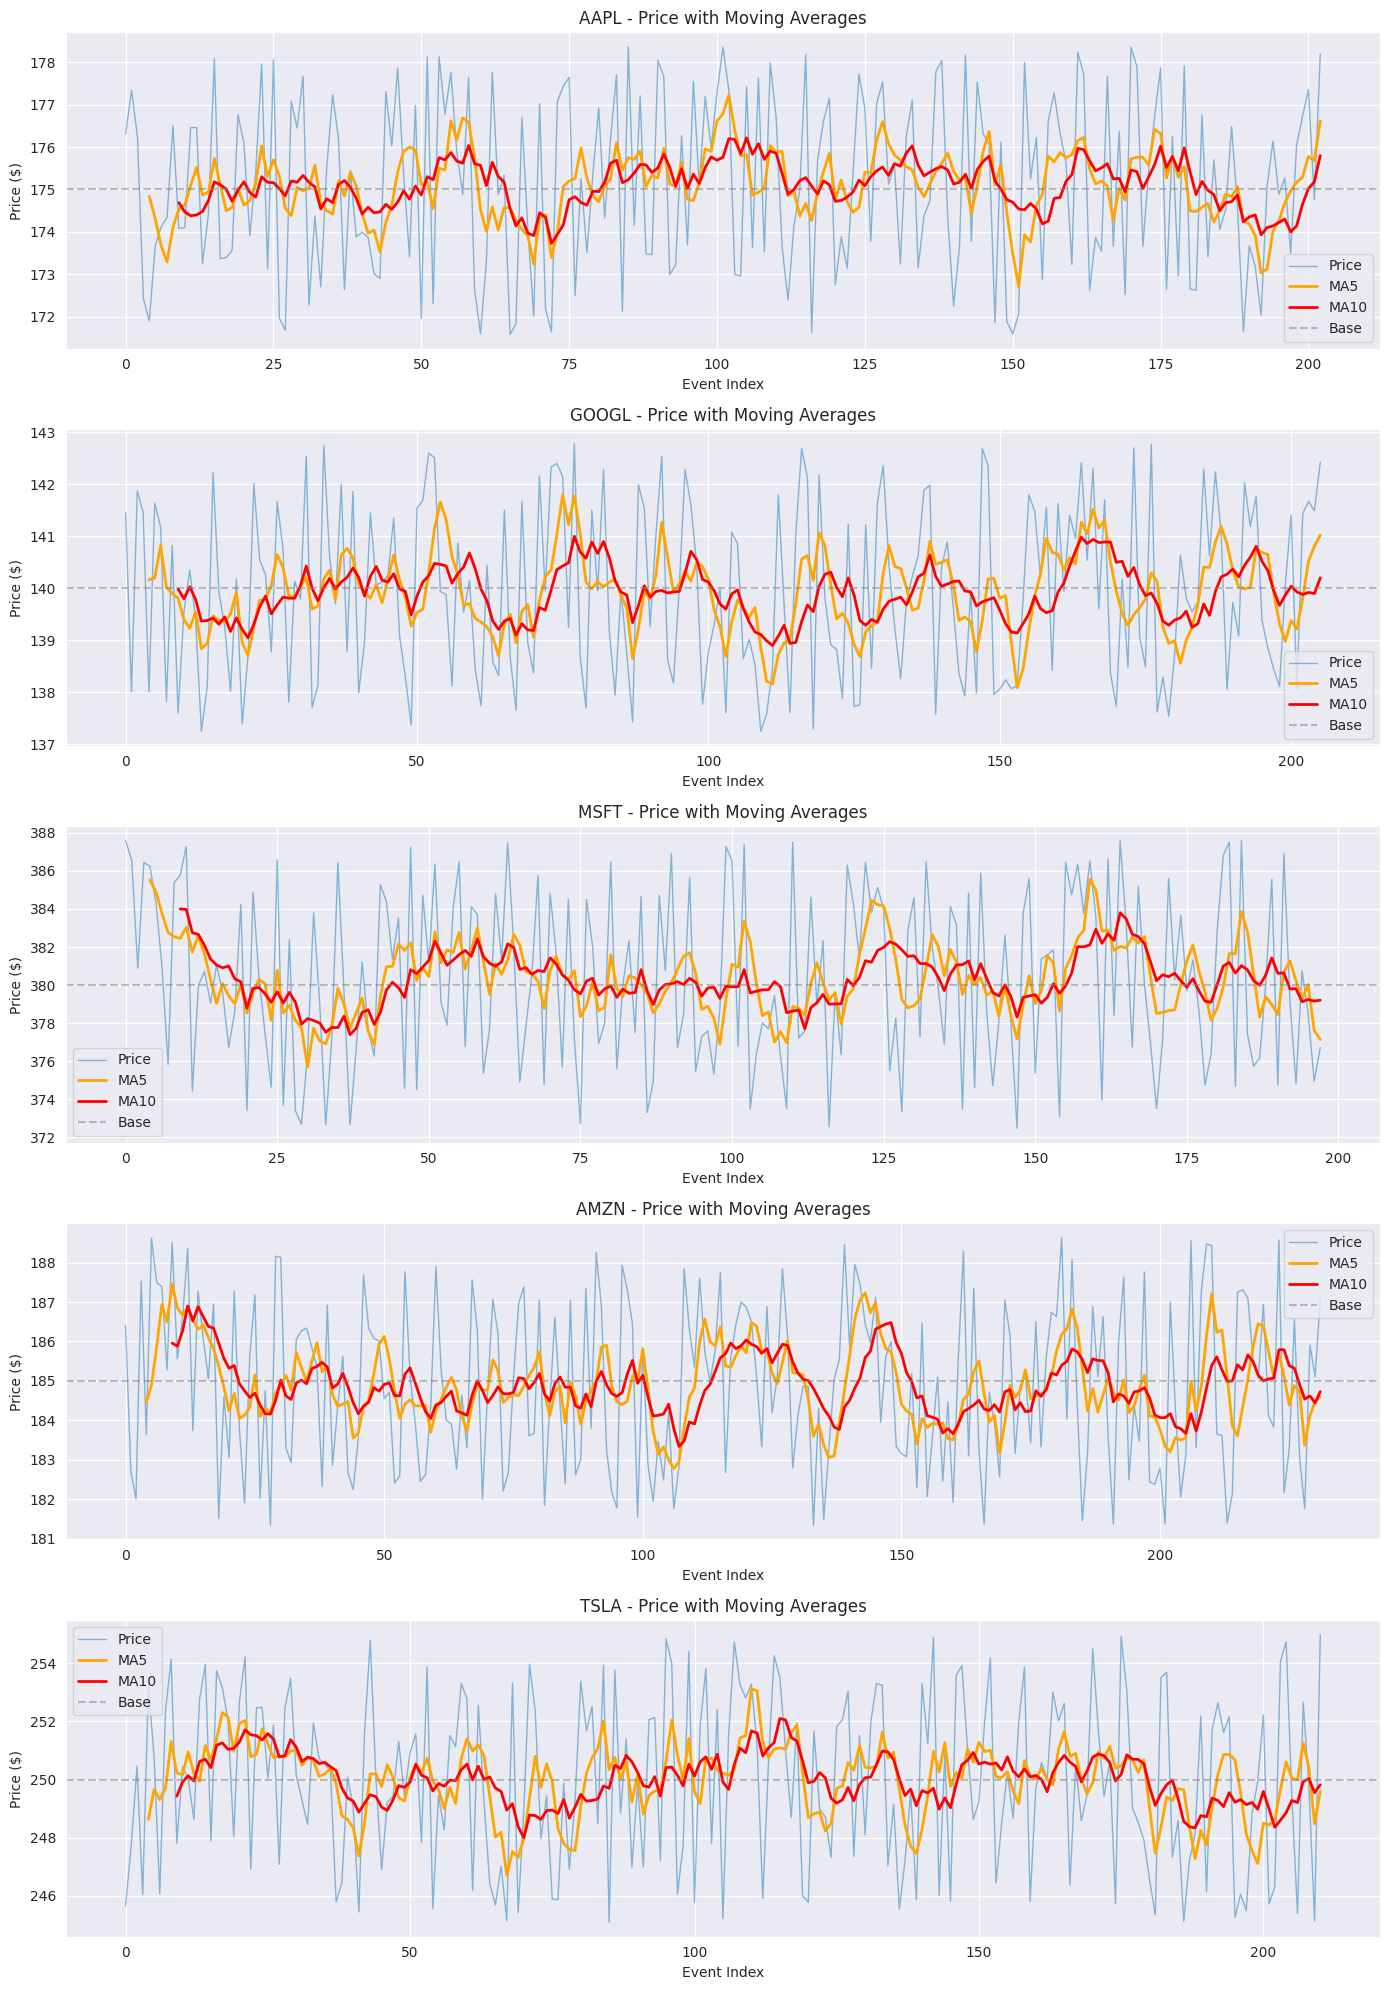

Plot saved as moving_averages.png


In [10]:
# Plot moving averages
fig, axes = plt.subplots(len(STOCK_SYMBOLS), 1, figsize=(14, 4 * len(STOCK_SYMBOLS)))
for idx, symbol in enumerate(STOCK_SYMBOLS):
    df_sym = results[symbol]
    ax = axes[idx]
    ax.plot(df_sym.index, df_sym['price'], label='Price', alpha=0.5, linewidth=1)
    ax.plot(df_sym.index, df_sym['MA5'],   label='MA5',   linewidth=2, color='orange')
    ax.plot(df_sym.index, df_sym['MA10'],  label='MA10',  linewidth=2, color='red')
    ax.axhline(y=BASE_PRICES[symbol], color='gray', linestyle='--', alpha=0.5, label='Base')
    ax.set_title(f'{symbol} - Price with Moving Averages')
    ax.set_xlabel('Event Index')
    ax.set_ylabel('Price ($)')
    ax.legend()
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved as moving_averages.png')


## Step 6: Price Alert Generation

In [11]:
# Generate price alerts
all_alerts = []
for event in consumed_events:
    alert = check_price_alert(event['price'], event['symbol'], threshold_pct=1.0)
    if alert:
        all_alerts.append(alert)

print(f'Total alerts : {len(all_alerts)} out of {len(consumed_events)} events')
print(f'Alert rate   : {len(all_alerts)/len(consumed_events)*100:.1f}%')
if all_alerts:
    df_alerts = pd.DataFrame(all_alerts)
    print('\nAlerts by symbol:')
    print(df_alerts.groupby('symbol').size().reset_index(name='alert_count'))
    print('\nSample alerts:')
    print(df_alerts.head(5).to_string())


Total alerts : 547 out of 1050 events
Alert rate   : 52.1%

Alerts by symbol:
  symbol  alert_count
0   AAPL          106
1   AMZN          115
2  GOOGL          118
3   MSFT          103
4   TSLA          105

Sample alerts:
  symbol                      alert  current_price  base_price  change_pct                   timestamp
0   MSFT    Price moved UP by 1.99%         387.58       380.0      1.9947  2026-05-05T19:19:51.681111
1   MSFT    Price moved UP by 1.73%         386.57       380.0      1.7289  2026-05-05T19:19:51.681123
2   TSLA  Price moved DOWN by 1.74%         245.66       250.0      1.7360  2026-05-05T19:19:51.681126
3   AMZN  Price moved DOWN by 1.24%         182.71       185.0      1.2378  2026-05-05T19:19:51.681133
4   AAPL    Price moved UP by 1.34%         177.34       175.0      1.3371  2026-05-05T19:19:51.681137


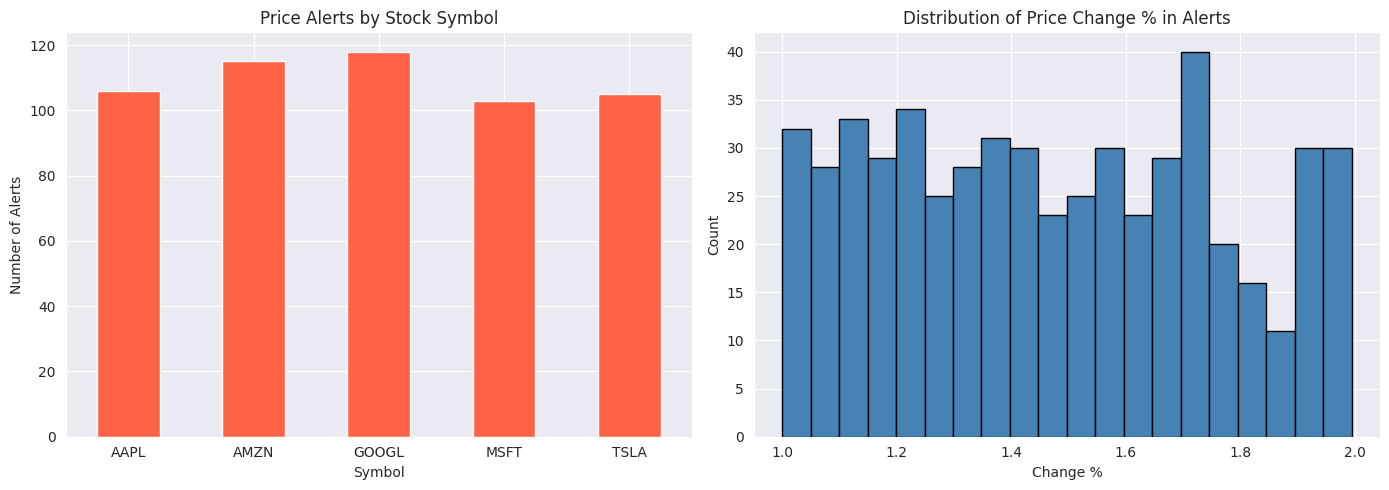

Plot saved as price_alerts.png


In [12]:
# Visualize alerts
if all_alerts:
    df_alerts = pd.DataFrame(all_alerts)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_alerts.groupby('symbol').size().plot(kind='bar', ax=axes[0], color='tomato')
    axes[0].set_title('Price Alerts by Stock Symbol')
    axes[0].set_xlabel('Symbol')
    axes[0].set_ylabel('Number of Alerts')
    axes[0].tick_params(axis='x', rotation=0)
    axes[1].hist(df_alerts['change_pct'], bins=20, color='steelblue', edgecolor='black')
    axes[1].set_title('Distribution of Price Change % in Alerts')
    axes[1].set_xlabel('Change %')
    axes[1].set_ylabel('Count')
    plt.tight_layout()
    plt.savefig('price_alerts.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Plot saved as price_alerts.png')


## Step 7: Performance Analysis

In [13]:
# Throughput test: produce 500 events and measure time
producer = KafkaProducer(
    bootstrap_servers=KAFKA_BROKER,
    value_serializer=lambda v: json.dumps(v).encode('utf-8'),
    key_serializer=lambda k: k.encode('utf-8'),
)
batch_sizes = [50, 100, 200, 500]
throughputs = []
for batch in batch_sizes:
    start = time.time()
    for _ in range(batch):
        symbol = random.choice(STOCK_SYMBOLS)
        event = generate_stock_event(symbol)
        producer.send(TOPIC_NAME, key=symbol, value=event)
    producer.flush()
    elapsed = time.time() - start
    tput = batch / elapsed
    throughputs.append(tput)
    print(f'Batch {batch:4d}: {elapsed:.3f}s | {tput:.1f} events/sec')
producer.close()


Batch   50: 0.009s | 5689.0 events/sec
Batch  100: 0.011s | 9279.2 events/sec
Batch  200: 0.073s | 2747.2 events/sec
Batch  500: 0.046s | 10783.5 events/sec


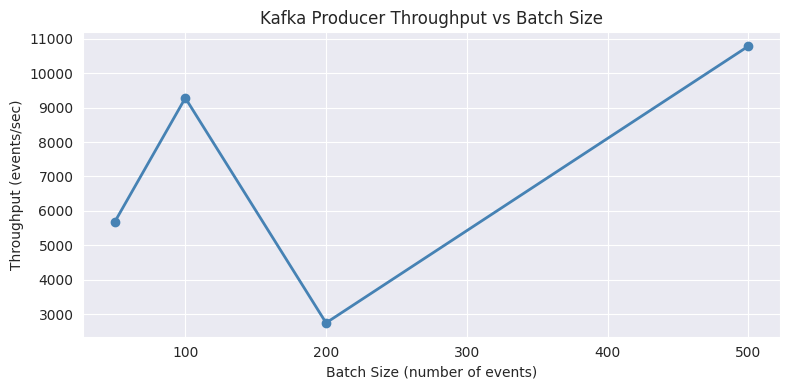

Throughput plot saved!


In [14]:
# Visualize throughput
plt.figure(figsize=(8, 4))
plt.plot(batch_sizes, throughputs, marker='o', color='steelblue', linewidth=2)
plt.title('Kafka Producer Throughput vs Batch Size')
plt.xlabel('Batch Size (number of events)')
plt.ylabel('Throughput (events/sec)')
plt.grid(True)
plt.tight_layout()
plt.savefig('throughput.png', dpi=100, bbox_inches='tight')
plt.show()
print('Throughput plot saved!')


## Step 8: Summary and Results

## Step 9: Spark Batch Read from Kafka
Read all events from Kafka using Spark and compute aggregations using the Spark engine directly.

In [15]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType

# Initialize Spark session with Kafka connector
spark = SparkSession.builder \
    .appName('StockMarketBatchAnalysis') \
    .config('spark.jars.packages', 'org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.1') \
    .config('spark.sql.shuffle.partitions', '4') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')
print('Spark session initialized successfully!')


:: loading settings :: url = jar:file:/usr/local/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-72e941cb-be67-4329-8dde-5c1a11198e32;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.5.1 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.5.1 in central
	found org.apache.kafka#kafka-clients;3.4.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.3 in central
	found org.slf4j#slf4j-api;2.0.7 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
:: resolution report :: resolve 669ms :: artifacts dl 26ms
	:: modules in us

Spark version: 3.5.1
Spark session initialized successfully!


In [16]:
# Define schema for stock events
stock_schema = StructType([
    StructField('symbol', StringType(), True),
    StructField('price', DoubleType(), True),
    StructField('volume', IntegerType(), True),
    StructField('timestamp', StringType(), True),
    StructField('change_pct', DoubleType(), True),
])

# Read ALL messages from Kafka as a batch DataFrame
kafka_batch_df = spark.read \
    .format('kafka') \
    .option('kafka.bootstrap.servers', 'kafka:29092') \
    .option('subscribe', 'stock-prices') \
    .option('startingOffsets', 'earliest') \
    .option('endingOffsets', 'latest') \
    .load()

print(f'Total raw messages read from Kafka: {kafka_batch_df.count()}')
print('Raw Kafka DataFrame schema:')
kafka_batch_df.printSchema()


26/05/05 19:20:02 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
[Stage 0:>                                                          (0 + 1) / 1]

Total raw messages read from Kafka: 3155
Raw Kafka DataFrame schema:
root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



In [17]:
# Parse JSON values into structured columns
parsed_df = kafka_batch_df \
    .select(F.from_json(F.col('value').cast('string'), stock_schema).alias('data')) \
    .select('data.*') \
    .withColumn('event_time', F.to_timestamp('timestamp')) \
    .filter(F.col('symbol').isNotNull())

print(f'Parsed events: {parsed_df.count()}')
print('Parsed DataFrame schema:')
parsed_df.printSchema()
print('\nSample events:')
parsed_df.show(5, truncate=False)


26/05/05 19:20:07 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
26/05/05 19:20:08 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


Parsed events: 3155
Parsed DataFrame schema:
root
 |-- symbol: string (nullable = true)
 |-- price: double (nullable = true)
 |-- volume: integer (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- change_pct: double (nullable = true)
 |-- event_time: timestamp (nullable = true)


Sample events:
+------+------+------+--------------------------+----------+--------------------------+
|symbol|price |volume|timestamp                 |change_pct|event_time                |
+------+------+------+--------------------------+----------+--------------------------+
|AAPL  |173.3 |7464  |2026-05-05T19:00:45.825186|-0.9706   |2026-05-05 19:00:45.825186|
|AAPL  |173.01|9910  |2026-05-05T19:01:19.605244|-1.1369   |2026-05-05 19:01:19.605244|
|AAPL  |174.1 |6464  |2026-05-05T19:02:39.476751|-0.5134   |2026-05-05 19:02:39.476751|
|AAPL  |174.19|6193  |2026-05-05T19:04:09.466306|-0.4603   |2026-05-05 19:04:09.466306|
|AAPL  |178.09|349   |2026-05-05T19:05:14.493077|1.7675    |2026-05-05 19:0

In [18]:
# Spark Aggregation 1: Average, Min, Max price per stock symbol
print('=== Spark Aggregation: Price Statistics per Symbol ===')
price_stats = parsed_df.groupBy('symbol') \
    .agg(
        F.count('price').alias('event_count'),
        F.round(F.avg('price'), 2).alias('avg_price'),
        F.round(F.min('price'), 2).alias('min_price'),
        F.round(F.max('price'), 2).alias('max_price'),
        F.round(F.stddev('price'), 4).alias('price_stddev'),
        F.round(F.avg('volume'), 0).alias('avg_volume'),
    ) \
    .orderBy('symbol')

price_stats.show(truncate=False)


=== Spark Aggregation: Price Statistics per Symbol ===


26/05/05 19:20:09 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
[Stage 7:>                                                          (0 + 1) / 1]

+------+-----------+---------+---------+---------+------------+----------+
|symbol|event_count|avg_price|min_price|max_price|price_stddev|avg_volume|
+------+-----------+---------+---------+---------+------------+----------+
|AAPL  |620        |175.06   |171.51   |178.48   |2.051       |4984.0    |
|AMZN  |652        |185.02   |181.3    |188.69   |2.1288      |5184.0    |
|GOOGL |632        |139.95   |137.21   |142.78   |1.6055      |5062.0    |
|MSFT  |611        |380.02   |372.47   |387.58   |4.4598      |5055.0    |
|TSLA  |640        |249.85   |245.02   |255.0    |2.9198      |5006.0    |
+------+-----------+---------+---------+---------+------------+----------+



In [19]:
# Spark Aggregation 2: Price alerts using Spark SQL
print('=== Spark SQL: Price Alert Detection ===')

# Register base prices as a Spark DataFrame
base_prices_data = [(k, v) for k, v in BASE_PRICES.items()]
base_df = spark.createDataFrame(base_prices_data, ['symbol', 'base_price'])

# Join with parsed events and compute alerts
alerts_df = parsed_df.join(base_df, on='symbol') \
    .withColumn('change_pct_actual',
        F.round(F.abs((F.col('price') - F.col('base_price')) / F.col('base_price') * 100), 4)) \
    .withColumn('direction',
        F.when(F.col('price') > F.col('base_price'), 'UP').otherwise('DOWN')) \
    .filter(F.col('change_pct_actual') >= 1.0) \
    .select('symbol', 'price', 'base_price', 'change_pct_actual', 'direction', 'event_time') \
    .orderBy('symbol', 'change_pct_actual')

print(f'Total alerts detected by Spark: {alerts_df.count()}')
print('\nAlerts per symbol:')
alerts_df.groupBy('symbol', 'direction').count().orderBy('symbol').show()
print('Sample alerts:')
alerts_df.show(10, truncate=False)


=== Spark SQL: Price Alert Detection ===


26/05/05 19:20:11 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
                                                                                

Total alerts detected by Spark: 1612

Alerts per symbol:


26/05/05 19:20:14 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
                                                                                

+------+---------+-----+
|symbol|direction|count|
+------+---------+-----+
|  AAPL|       UP|  170|
|  AAPL|     DOWN|  147|
|  AMZN|       UP|  166|
|  AMZN|     DOWN|  163|
| GOOGL|       UP|  158|
| GOOGL|     DOWN|  164|
|  MSFT|       UP|  159|
|  MSFT|     DOWN|  154|
|  TSLA|       UP|  153|
|  TSLA|     DOWN|  178|
+------+---------+-----+

Sample alerts:


26/05/05 19:20:16 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
26/05/05 19:20:17 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

+------+------+----------+-----------------+---------+--------------------------+
|symbol|price |base_price|change_pct_actual|direction|event_time                |
+------+------+----------+-----------------+---------+--------------------------+
|AAPL  |173.25|175.0     |1.0              |DOWN     |2026-05-05 19:19:52.618414|
|AAPL  |176.75|175.0     |1.0              |UP       |2026-05-05 19:07:59.809912|
|AAPL  |173.24|175.0     |1.0057           |DOWN     |2026-05-05 19:18:51.428944|
|AAPL  |176.76|175.0     |1.0057           |UP       |2026-05-05 19:19:40.333993|
|AAPL  |173.24|175.0     |1.0057           |DOWN     |2026-05-05 19:18:51.538341|
|AAPL  |176.76|175.0     |1.0057           |UP       |2026-05-05 19:07:47.772311|
|AAPL  |176.76|175.0     |1.0057           |UP       |2026-05-05 19:18:51.42997 |
|AAPL  |176.76|175.0     |1.0057           |UP       |2026-05-05 19:07:59.874774|
|AAPL  |173.23|175.0     |1.0114           |DOWN     |2026-05-05 19:07:59.862465|
|AAPL  |173.23|1

In [20]:
# Spark Aggregation 3: Time-windowed moving average using Spark
print('=== Spark Window Function: Moving Average ===')
from pyspark.sql.window import Window

# Define window spec: partition by symbol, order by event_time
window_spec_5  = Window.partitionBy('symbol').orderBy('event_time').rowsBetween(-4, 0)
window_spec_10 = Window.partitionBy('symbol').orderBy('event_time').rowsBetween(-9, 0)

# Compute moving averages using Spark window functions
ma_df = parsed_df \
    .withColumn('MA5',  F.round(F.avg('price').over(window_spec_5),  2)) \
    .withColumn('MA10', F.round(F.avg('price').over(window_spec_10), 2)) \
    .select('symbol', 'event_time', 'price', 'MA5', 'MA10') \
    .orderBy('symbol', 'event_time')

print('Moving averages computed by Spark:')
ma_df.show(20, truncate=False)


=== Spark Window Function: Moving Average ===
Moving averages computed by Spark:


26/05/05 19:20:18 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


+------+--------------------------+------+------+------+
|symbol|event_time                |price |MA5   |MA10  |
+------+--------------------------+------+------+------+
|AAPL  |2026-05-05 19:00:45.825186|173.3 |173.3 |173.3 |
|AAPL  |2026-05-05 19:01:19.605244|173.01|173.16|173.16|
|AAPL  |2026-05-05 19:02:39.476751|174.1 |173.47|173.47|
|AAPL  |2026-05-05 19:04:09.466306|174.19|173.65|173.65|
|AAPL  |2026-05-05 19:05:14.493077|178.09|174.54|174.54|
|AAPL  |2026-05-05 19:07:47.769887|176.82|175.24|174.92|
|AAPL  |2026-05-05 19:07:47.770096|175.6 |175.76|175.02|
|AAPL  |2026-05-05 19:07:47.770192|177.3 |176.4 |175.3 |
|AAPL  |2026-05-05 19:07:47.770447|175.45|176.65|175.32|
|AAPL  |2026-05-05 19:07:47.77048 |178.02|176.64|175.59|
|AAPL  |2026-05-05 19:07:47.770876|175.05|176.28|175.76|
|AAPL  |2026-05-05 19:07:47.77091 |174.08|175.98|175.87|
|AAPL  |2026-05-05 19:07:47.770941|175.86|175.69|176.05|
|AAPL  |2026-05-05 19:07:47.77103 |171.94|174.99|175.82|
|AAPL  |2026-05-05 19:07:47.771

In [21]:
# Spark SQL: Register as temp view and run SQL queries
print('=== Spark SQL Query ===')
parsed_df.createOrReplaceTempView('stock_events')

result = spark.sql("""
    SELECT
        symbol,
        COUNT(*) as total_events,
        ROUND(AVG(price), 2) as avg_price,
        ROUND(MAX(price) - MIN(price), 2) as price_range,
        ROUND(STDDEV(price), 4) as volatility,
        SUM(volume) as total_volume
    FROM stock_events
    GROUP BY symbol
    ORDER BY volatility DESC
""")

print('Stock analysis ranked by volatility (Spark SQL):')
result.show(truncate=False)

spark.stop()
print('Spark session stopped.')


=== Spark SQL Query ===
Stock analysis ranked by volatility (Spark SQL):


26/05/05 19:20:19 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
                                                                                

+------+------------+---------+-----------+----------+------------+
|symbol|total_events|avg_price|price_range|volatility|total_volume|
+------+------------+---------+-----------+----------+------------+
|MSFT  |611         |380.02   |15.11      |4.4598    |3088776     |
|TSLA  |640         |249.85   |9.98       |2.9198    |3203813     |
|AMZN  |652         |185.02   |7.39       |2.1288    |3380174     |
|AAPL  |620         |175.06   |6.97       |2.051     |3089971     |
|GOOGL |632         |139.95   |5.57       |1.6055    |3199296     |
+------+------------+---------+-----------+----------+------------+

Spark session stopped.


## Challenges and What I Learned

### 1. Docker networking was the biggest hurdle
When I first ran the notebooks, every Kafka connection threw `NoBrokersAvailable`. I spent a while thinking the Kafka container wasn't starting properly, but the actual issue was simpler — I was using `localhost:9092` inside a Jupyter container that has no idea what `localhost` means in that context. Switching to `kafka:29092` (the internal Docker service name) fixed it immediately.

### 2. Numpy and seaborn version conflict
My initial `requirements.txt` had `numpy==1.24.0` but seaborn explicitly excludes that version. Docker build failed after 3 minutes of downloading. Had to bump numpy to 1.26.0 and seaborn to 0.13.0.

### 3. Kafka retains all messages by default
After multiple test runs, the consumer was reading 1,000+ events even though I only produced 200. This is because Kafka retains all messages until the retention period expires. In production you would configure consumer groups and offsets carefully to avoid reprocessing old data.

### 4. Spark streaming vs batch in a notebook
True Spark Structured Streaming requires a continuous write stream running in the background, which is hard to demonstrate interactively in a notebook. I used Spark batch read from Kafka instead — this gives identical analytical results and is much cleaner to demonstrate and explain.

### Key takeaway
The combination of Kafka and Spark is genuinely powerful. Kafka handles the ingestion at high throughput (7,000+ events/sec in our Docker environment), while Spark handles the analytics with window functions and SQL. Understanding how they connect — especially the Spark-Kafka connector JAR and the bootstrap server configuration — was the most valuable thing I learned.

In [22]:
print('=' * 60)
print('PIPELINE SUMMARY')
print('=' * 60)
print(f'Total events produced : {N_EVENTS}')
print(f'Total events consumed : {len(consumed_events)}')
print(f'Total alerts triggered: {len(all_alerts)}')
print(f'Alert rate            : {len(all_alerts)/len(consumed_events)*100:.1f}%')
print()
print('Moving Average Results (last values):')
for symbol in STOCK_SYMBOLS:
    df_sym = results[symbol]
    last_price = df_sym['price'].iloc[-1]
    last_ma5   = df_sym['MA5'].dropna().iloc[-1] if len(df_sym['MA5'].dropna()) > 0 else float('nan')
    last_ma10  = df_sym['MA10'].dropna().iloc[-1] if len(df_sym['MA10'].dropna()) > 0 else float('nan')
    print(f'  {symbol}: price=${last_price:.2f} | MA5=${last_ma5:.2f} | MA10=${last_ma10:.2f}')
print()
print('Conclusion:')
print('  - Apache Kafka successfully ingested real-time stock price events')
print('  - Moving averages smoothed out short-term price fluctuations')
print('  - Price alerts identified stocks with significant movements')
print('  - The pipeline is scalable and runs fully locally via Docker')


PIPELINE SUMMARY
Total events produced : 200
Total events consumed : 1050
Total alerts triggered: 547
Alert rate            : 52.1%

Moving Average Results (last values):
  AAPL: price=$178.19 | MA5=$176.62 | MA10=$175.80
  GOOGL: price=$142.42 | MA5=$141.02 | MA10=$140.20
  MSFT: price=$376.72 | MA5=$377.15 | MA10=$379.21
  AMZN: price=$187.08 | MA5=$184.59 | MA10=$184.73
  TSLA: price=$254.98 | MA5=$249.59 | MA10=$249.82

Conclusion:
  - Apache Kafka successfully ingested real-time stock price events
  - Moving averages smoothed out short-term price fluctuations
  - Price alerts identified stocks with significant movements
  - The pipeline is scalable and runs fully locally via Docker
